In [161]:
import xmitgcm

ds = xmitgcm.open_mdsdataset(data_dir='./input/output/', grid_dir='./input', prefix=['surf','state','pollutant_tendency','pollutant_state'], delta_t=900)
ds

/home/rugkey/miniconda3/envs/MITgcm/lib/python3.12/site-packages/xmitgcm/mds_store.py:289: FutureWarning: In a future version, xarray will not decode the variable 'time' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  ds['time'] = xr.decode_cf(ds[['time']])['time']
/home/rugkey/miniconda3/envs/MITgcm/lib/python3.12/site-packages/xmitgcm/mds_store.py:289: FutureWarning: In a future version, xarray will not decode the variable 'time' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presenc

<xarray.Dataset> Size: 93MB
Dimensions:   (XC: 180, YC: 80, XG: 180, YG: 80, Z: 40, Zp1: 41, Zu: 40,
               Zl: 40, time: 3)
Coordinates: (12/34)
  * XC        (XC) >f4 720B 1.0 3.0 5.0 7.0 9.0 ... 353.0 355.0 357.0 359.0
  * YC        (YC) >f4 320B -79.0 -77.0 -75.0 -73.0 ... 73.0 75.0 77.0 79.0
  * XG        (XG) >f4 720B 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0
  * YG        (YG) >f4 320B -80.0 -78.0 -76.0 -74.0 ... 72.0 74.0 76.0 78.0
  * Z         (Z) >f4 160B -5.01 -15.07 -25.28 ... -5.125e+03 -5.375e+03
  * Zp1       (Zp1) >f4 164B 0.0 -10.04 -20.17 ... -5e+03 -5.25e+03 -5.625e+03
    ...        ...
    dyF       (YC, XC) >f4 58kB dask.array<chunksize=(80, 180), meta=np.ndarray>
    dyU       (YG, XG) >f4 58kB dask.array<chunksize=(80, 180), meta=np.ndarray>
    rhoRef    (Z) >f4 160B dask.array<chunksize=(40,), meta=np.ndarray>
    dxF       (YC, XC) >f4 58kB dask.array<chunksize=(80, 180), meta=np.ndarray>
    dxV       (YG, XG) >f4 58kB dask.array<chunksize=(80, 180), meta=np.ndarray>
    iter      (time) int64 24B dask.array<chunksize=(1,), meta=np.ndarray>
Data variables: (12/13)
    TRAC01    (time, Z, YC, XC) float32 7MB dask.array<chunksize=(1, 40, 80, 180), meta=np.ndarray>
    POLLUT_M  (time, Z, YC, XC) float32 7MB dask.array<chunksize=(1, 40, 80, 180), meta=np.ndarray>
    ETAN      (time, YC, XC) float32 173kB dask.array<chunksize=(1, 80, 180), meta=np.ndarray>
    UVEL      (time, Z, YC, XG) float32 7MB dask.array<chunksize=(1, 40, 80, 180), meta=np.ndarray>
    VVEL      (time, Z, YG, XC) float32 7MB dask.array<chunksize=(1, 40, 80, 180), meta=np.ndarray>
    THETA     (time, Z, YC, XC) float32 7MB dask.array<chunksize=(1, 40, 80, 180), meta=np.ndarray>
    ...        ...
    POLLUT_S  (time, Z, YC, XC) float32 7MB dask.array<chunksize=(1, 40, 80, 180), meta=np.ndarray>
    POLLUT_K  (time, Z, YC, XC) float32 7MB dask.array<chunksize=(1, 40, 80, 180), meta=np.ndarray>
    POLLUT_D  (time, Z, YC, XC) float32 7MB dask.array<chunksize=(1, 40, 80, 180), meta=np.ndarray>
    POLLUT_L  (time, Z, YC, XC) float32 7MB dask.array<chunksize=(1, 40, 80, 180), meta=np.ndarray>
    POLLUT_B  (time, Z, YC, XC) float32 7MB dask.array<chunksize=(1, 40, 80, 180), meta=np.ndarray>
    POLLUT_T  (time, Z, YC, XC) float32 7MB dask.array<chunksize=(1, 40, 80, 180), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.6
    title:        netCDF wrapper of MITgcm MDS binary data
    source:       MITgcm
    history:      Created by calling `open_mdsdataset(data_dir='./input/outpu...

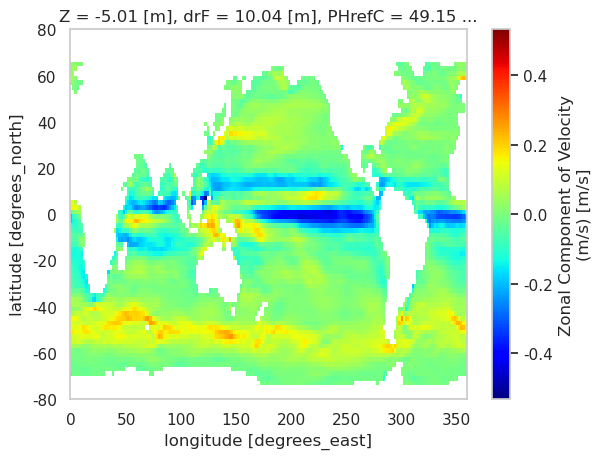

In [162]:
import numpy as np
ds.UVEL.where(ds.UVEL!=0)[-1, 0].plot(cmap='jet')

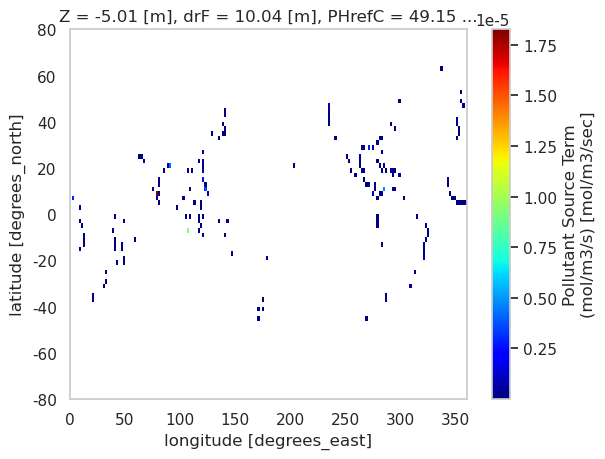

In [163]:
import numpy as np
ds.POLLUT_S.where(ds.POLLUT_S!=0)[-1,0].plot(cmap='jet')

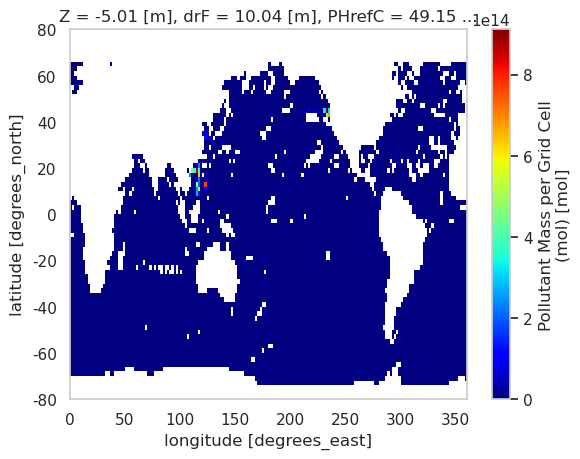

In [164]:
ds.POLLUT_M.where(ds.POLLUT_M!=0)[-1,0].plot(cmap='jet')

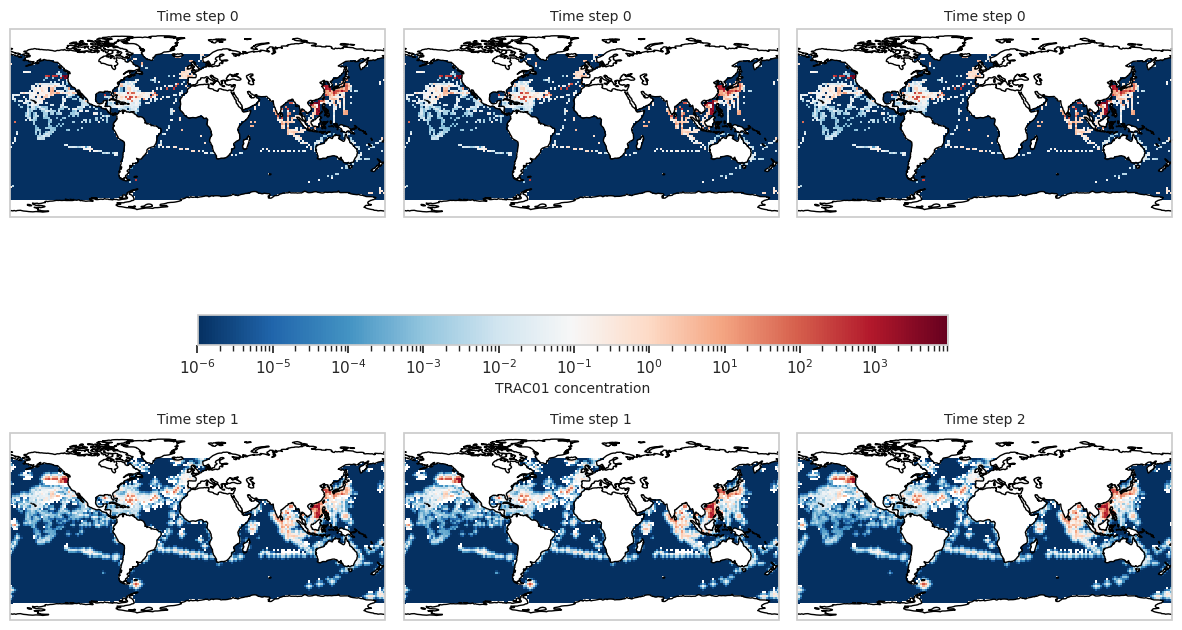

In [165]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from matplotlib.colors import LogNorm
import seaborn as sns

# 设置 Seaborn 样式
sns.set(style="whitegrid", palette="Oranges")  # whitegrid 风格 + viridis 配色

# 时间步选择，均分 6 个
n_panels = 6
time_indices = np.linspace(0, ds.TRAC01.shape[0]-1, n_panels, dtype=int)

# 数据范围
vmin = max(1e-6, np.nanmin(ds.TRAC01.values))
vmax = np.nanmax(ds.TRAC01.values)

# 创建 2x3 子图
fig, axes = plt.subplots(2, 3, figsize=(15, 10),
                         subplot_kw={'projection': ccrs.PlateCarree()})
fig.subplots_adjust(hspace=0.1, wspace=0.05)

axes = axes.flatten()

# 简化循环，绘制每个时间步
for ax, t in zip(axes, time_indices):
    data = ds.TRAC01.where(ds.TRAC01 != 0).isel(time=t, Z=0)
    
    # 获取经纬度
    lon = data.coords.get('XC', data.coords.get('X', np.arange(data.shape[1]))).values
    lat = data.coords.get('YC', data.coords.get('Y', np.arange(data.shape[0]))).values
    
    # 绘制二维分布
    im = ax.pcolormesh(lon, lat, data.values,
                       transform=ccrs.PlateCarree(),
                       cmap='RdBu_r',   # 使用 Seaborn 调色板的类似颜色
                       norm=LogNorm(vmin=vmin, vmax=vmax),
                       shading='auto')
    
    ax.coastlines(resolution='110m')
    ax.set_global()
    ax.set_title(f'Time step {t}', fontsize=10)

# 横向 colorbar，垂直中间
cbar_ax = fig.add_axes([0.25, 0.475, 0.5, 0.03])
cb = plt.colorbar(im, cax=cbar_ax, orientation='horizontal')
cb.set_label('TRAC01 concentration', fontsize=10)

# 保存高分辨率图片
plt.savefig('TRAC01_2x3_grid_middle_colorbar_seaborn.png', dpi=600, bbox_inches='tight')
plt.show()


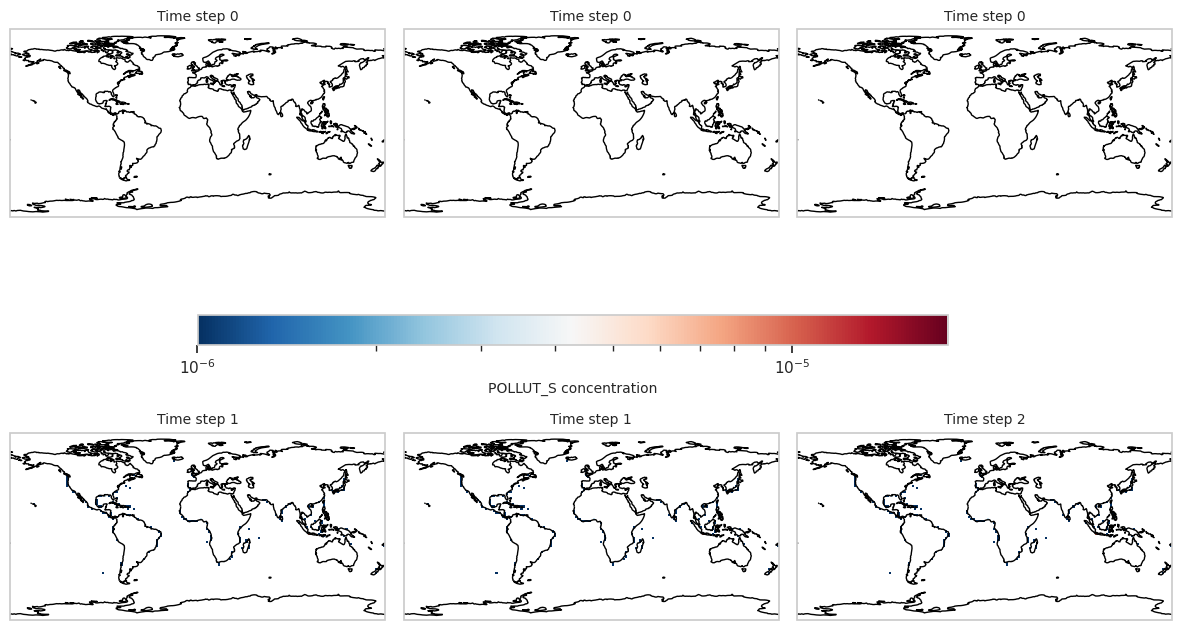

In [166]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from matplotlib.colors import LogNorm
import seaborn as sns

# 设置 Seaborn 样式
sns.set(style="whitegrid", palette="Oranges")  # whitegrid 风格 + viridis 配色

# 时间步选择，均分 6 个
n_panels = 6
time_indices = np.linspace(0, ds.POLLUT_S.shape[0]-1, n_panels, dtype=int)

# 数据范围
vmin = max(1e-6, np.nanmin(ds.POLLUT_S.values))
vmax = np.nanmax(ds.POLLUT_S.values)

# 创建 2x3 子图
fig, axes = plt.subplots(2, 3, figsize=(15, 10),
                         subplot_kw={'projection': ccrs.PlateCarree()})
fig.subplots_adjust(hspace=0.1, wspace=0.05)

axes = axes.flatten()

# 简化循环，绘制每个时间步
for ax, t in zip(axes, time_indices):
    data = ds.POLLUT_S.where(ds.POLLUT_S != 0).isel(time=t, Z=0)
    
    # 获取经纬度
    lon = data.coords.get('XC', data.coords.get('X', np.arange(data.shape[1]))).values
    lat = data.coords.get('YC', data.coords.get('Y', np.arange(data.shape[0]))).values
    
    # 绘制二维分布
    im = ax.pcolormesh(lon, lat, data.values,
                       transform=ccrs.PlateCarree(),
                       cmap='RdBu_r',   # 使用 Seaborn 调色板的类似颜色
                       norm=LogNorm(vmin=vmin, vmax=vmax),
                       shading='auto')
    
    ax.coastlines(resolution='110m')
    ax.set_global()
    ax.set_title(f'Time step {t}', fontsize=10)

# 横向 colorbar，垂直中间
cbar_ax = fig.add_axes([0.25, 0.475, 0.5, 0.03])
cb = plt.colorbar(im, cax=cbar_ax, orientation='horizontal')
cb.set_label('POLLUT_S concentration', fontsize=10)

# 保存高分辨率图片
plt.savefig('POLLUT_S_2x3_grid_middle_colorbar_seaborn.png', dpi=600, bbox_inches='tight')
plt.show()
